In [13]:
import openeo
from openeo.processes import process
from IPython.display import Image

connection = openeo.connect("http://127.0.0.1:8085/")

In [14]:
connection.authenticate_basic(username="test", password="test")

<Connection to 'http://127.0.0.1:8085/' with BasicBearerAuth>

In [15]:
connection.auth.bearer

'basic//dGVzdDp0ZXN0'

In [16]:
# connection.list_collection_ids()

In [17]:
collection_info = connection.describe_collection("sentinel-2-global-mosaics")

In [18]:
collection_info

{'stac_version': '1.1.0',
 'stac_extensions': ['https://stac-extensions.github.io/eo/v2.0.0/schema.json',
  'https://stac-extensions.github.io/authentication/v1.1.0/schema.json',
  'https://stac-extensions.github.io/projection/v2.0.0/schema.json',
  'https://stac-extensions.github.io/processing/v1.2.0/schema.json',
  'https://stac-extensions.github.io/product/v0.1.0/schema.json',
  'https://stac-extensions.github.io/scientific/v1.0.0/schema.json',
  'https://stac-extensions.github.io/alternate-assets/v1.2.0/schema.json',
  'https://stac-extensions.github.io/storage/v2.0.0/schema.json',
  'https://stac-extensions.github.io/version/v1.2.0/schema.json',
  'https://stac-extensions.github.io/datacube/v2.2.0/schema.json',
  'https://stac-extensions.github.io/item-assets/v1.0.0/schema.json'],
 'type': 'Collection',
 'id': 'sentinel-2-global-mosaics',
 'title': 'Sentinel-2 Global Mosaics',
 'description': 'The mosaics have four bands of data (Red (B04), Green (B03), Blue (B02) and wide band Near Infrared (B08)). First, cloud masking based on the scene classification layer of the Sentinel-2 level 2 algorithm was applied, then for each pixel and band, within three-month time periods, the first quartile of the distribution of the pixel values was taken as the output value to filter out any bright pixels misclassified as not clouds. If there are no valid pixels for the given timeframe, the pixel is left empty. Sentinel-2 cloudless mosaics can be used for various purposes such as land cover classification, land use planning, or for the creation of basemaps. These images are especially useful for showing large and cloudy areas with interesting large-scale patterns. Iceland is a prime example, with frequent cloud cover and large areal extent spanning several Sentinel-2 swaths.',
 'keywords': ['Copernicus',
  'Sentinel',
  'EU',
  'ESA',
  'Satellite',
  'Global',
  'Imagery',
  'Reflectance',
  'EU',
  'EC'],
 'version': '1.0.0',
 'deprecated': False,
 'license': 'other',
 'providers': [{'name': 'ESA',
   'roles': ['producer'],
   'url': 'https://sentinels.copernicus.eu/web/sentinel/copernicus/sentinel-2'},
  {'name': 'European Commission',
   'roles': ['licensor'],
   'url': 'https://commission.europa.eu/'},
  {'name': 'CloudFerro', 'roles': ['host'], 'url': 'https://cloudferro.com/'}],
 'extent': {'spatial': {'bbox': [[-180.0, -90.0, 180.0, 90.0]]},
  'temporal': {'interval': [['2020-01-01T00:00:00Z', None]]}},
 'links': [],
 'cube:dimensions': {'x': {'type': 'spatial',
   'axis': 'x',
   'extent': [-180, 180]},
  'y': {'type': 'spatial', 'axis': 'y', 'extent': [-90, 90]},
  't': {'type': 'temporal', 'extent': ['2020-01-01T00:00:00Z', None]},
  'spectral': {'type': 'bands',
   'values': ['B08', 'Product', 'B02', 'B03', 'observations', 'B04']}},
 'summaries': {'gsd': [10],
  'instruments': ['msi'],
  'product:type': ['S2MSI_L3__MCQ'],
  'constellation': ['sentinel-2'],
  'processing:level': ['L3'],
  'product:timeliness': ['P3M'],
  'processing:facility': ['Copernicus Data Space Ecosystem']},
 'assets': {'thumbnail': {'href': 'https://s3.waw3-2.cloudferro.com/swift/v1/stac-png/Global-Mosaics.jpg',
   'title': 'Sentinel 2 Global Mosaics Thumbnail',
   'type': 'image/jpeg',
   'roles': ['thumbnail']}}}

In [19]:
spatial_extent_east = -73.90
spatial_extent_north = 40.80
spatial_extent_south = 40.70
spatial_extent_west = -74.00

In [20]:
load1 = connection.datacube_from_process(
    "load_collection",
    id="sentinel-2-global-mosaics",
    bands=["B04", "B03", "B02"],
    properties={},
    spatial_extent={
        "east": spatial_extent_east,
        "north": spatial_extent_north,
        "south": spatial_extent_south,
        "west": spatial_extent_west,
    },
    temporal_extent=["2022-04-15T00:00:00Z", "2022-12-31T00:00:00Z"],
)
load1 = load1.reduce_dimension(
    dimension="time",
    reducer="first",
)

In [21]:
def process1(x, context=None):
    data1 = process(
        "linear_scale_range", inputMax=10000, inputMin=0, outputMax=255, x=x
    )
    data2 = process("trunc", x=data1)
    return data2

In [22]:
processed = load1.apply(process=process1)

color = processed.process(
    "color_formula",
    data=processed,
    formula="Gamma RGB 1.5 Sigmoidal RGB 6 0.3 Saturation 1",
)

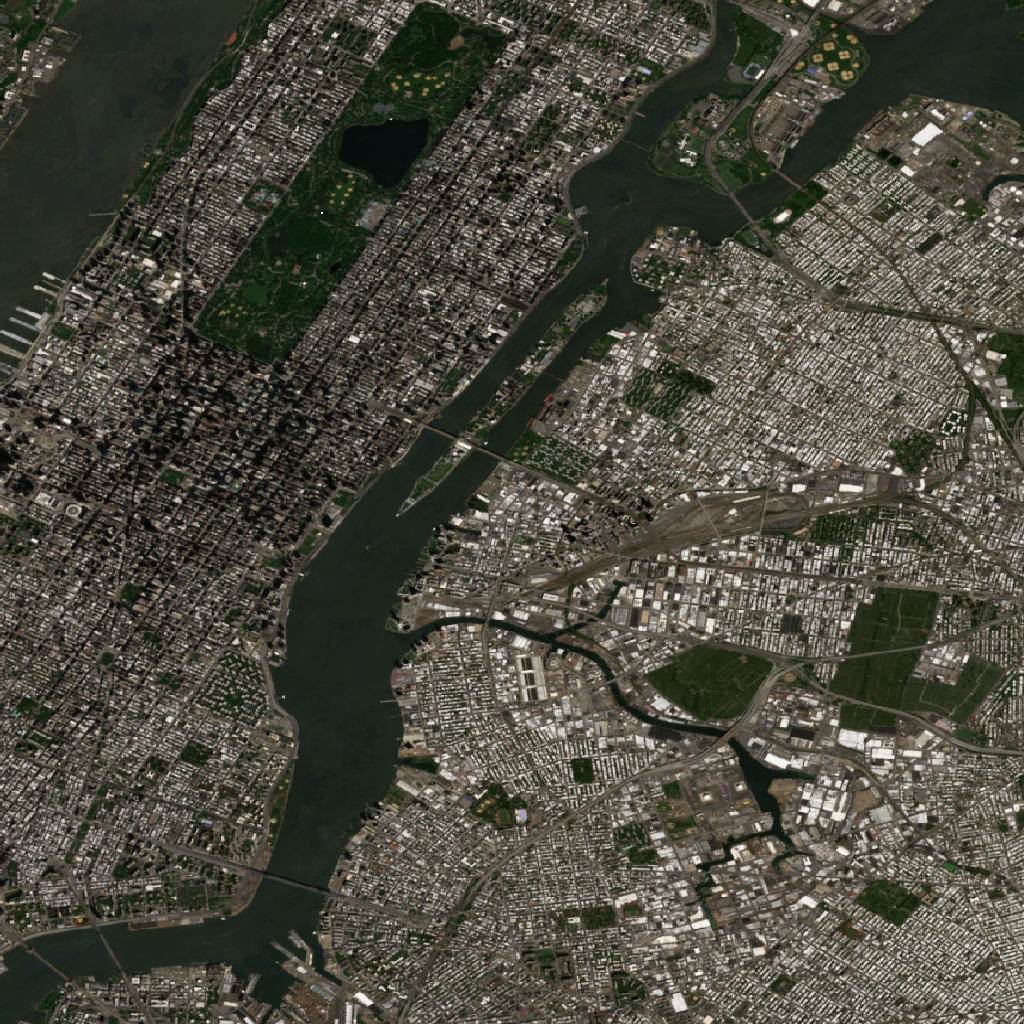

In [25]:
color.save_result(format="GTIFF")

with open("manhattan_openeo_graph.json", "w") as fobj:
    fobj.write(save.to_json())

save_png = color.save_result(format="PNG")

# The process can be executed synchronously (see below), as batch job or as web service now
result = connection.download(save_png)
Image(result)

In [29]:
connection.auth.bearer

'basic//dGVzdDp0ZXN0'